# DenseNet121 Staged Fine-tuning

Model setting:

- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: Class-weighted CrossEntropyLoss
- Optimizer: AdamW
- Training strategy: staged fine-tuning
- Stage 1: freeze DenseNet feature extractor and train classifier only
- Stage 2: unfreeze all layers and fine-tune with a smaller learning rate
- Stage 1 learning rate: 1e-3
- Stage 2 learning rate: 1e-5
- Batch size: 32
- Best model selection: validation QWK


In [13]:
EXPERIMENT_NAME = "densenet121_staged_weighted_ce_adamw"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32

STAGE1_EPOCHS = 8
STAGE1_LR = 1e-3
STAGE1_PATIENCE = 4

STAGE2_EPOCHS = 25
STAGE2_LR = 1e-5
STAGE2_PATIENCE = 7

MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)
print("Stage 1 epochs:", STAGE1_EPOCHS)
print("Stage 2 epochs:", STAGE2_EPOCHS)
print("Monitor metric:", MONITOR_METRIC)


Experiment: densenet121_staged_weighted_ce_adamw
Stage 1 epochs: 8
Stage 2 epochs: 25
Monitor metric: qwk


In [14]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: D:\760-Group1-main\wanqian
Project root: D:\760-Group1-main
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [15]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

# Stage 1: freeze DenseNet feature extractor
for param in model.features.parameters():
    param.requires_grad = False

trainable_params, total_params = count_trainable_parameters(model)

print("Stage 1: classifier-only training")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cpu
Stage 1: classifier-only training
Trainable parameters: 5,125
Total parameters:     6,958,981


In [16]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [17]:
# loss and optimizer: class-weighted CrossEntropyLoss + AdamW

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_dataset.samples]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=1e-4
)

Class weights: tensor([0.6481, 0.6649, 1.5284, 1.6787, 1.4222])


## create densenet

In [6]:
from utils.train_utils import train_model
import pandas as pd

# =========================
# Stage 1: train classifier only
# =========================

stage1_save_path = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}_stage1.pth"

model, history_stage1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=STAGE1_EPOCHS,
    save_path=stage1_save_path,
    monitor_metric=MONITOR_METRIC,
    patience=STAGE1_PATIENCE,
    min_delta=1e-4,
)

history_stage1["stage"] = "stage1_classifier_only"

print("Stage 1 finished.")
print("Saved Stage 1 model to:", stage1_save_path)


# =========================
# Stage 2: unfreeze all layers and fine-tune
# =========================

for param in model.features.parameters():
    param.requires_grad = True

trainable_params, total_params = count_trainable_parameters(model)

print("Stage 2: full fine-tuning")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=1e-4
)

stage2_save_path = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=STAGE2_EPOCHS,
    save_path=stage2_save_path,
    monitor_metric=MONITOR_METRIC,
    patience=STAGE2_PATIENCE,
    min_delta=1e-4,
)

history_stage2["stage"] = "stage2_full_finetuning"

# Combine histories
history_stage2["epoch"] = history_stage2["epoch"] + history_stage1["epoch"].max()

history_df = pd.concat(
    [history_stage1, history_stage2],
    ignore_index=True
)

print("Stage 2 finished.")
print("Saved final model to:", stage2_save_path)

history_df.tail()





Epoch 1/8
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.6201 | Train Acc: 0.2822 | Train Macro F1: 0.2621 | Train QWK: 0.1854
Val Loss:   1.4505 | Val Acc:   0.4247 | Val Macro F1: 0.4309 | Val QWK:   0.4809 | Val MAE:   1.0274
New best model found at epoch 1.
Best val qwk: 0.4809
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_staged_weighted_ce_adamw_stage1.pth

Epoch 2/8
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Train Loss: 0.4894 | Train Acc: 0.8105 | Train Macro F1: 0.8183 | Train QWK: 0.9105
Val Loss:   0.6612 | Val Acc:   0.7603 | Val Macro F1: 0.7318 | Val QWK:   0.8997 | Val MAE:   0.2877
No improvement in val qwk. Patience: 2/7

Epoch 25/25
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.4984 | Train Acc: 0.8252 | Train Macro F1: 0.8229 | Train QWK: 0.9148
Val Loss:   0.6519 | Val Acc:   0.7808 | Val Macro F1: 0.7548 | Val QWK:   0.9004 | Val MAE:   0.2671
No improvement in val qwk. Patience: 3/7
Stage 2 finished.
Saved final model to: D:\760-Group1-main\outputs\models\densenet121_staged_weighted_ce_adamw.pth


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate,stage
27,28,0.541629,0.681396,20,0,0.808594,0.807964,0.807295,0.242188,0.907152,...,0.761649,0.280822,0.895074,33,28,5,0.226027,0.191781,0.034247,stage2_full_finetuning
28,29,0.554686,0.674833,20,1,0.802734,0.804638,0.802139,0.262695,0.893817,...,0.776636,0.253425,0.913222,31,27,4,0.212329,0.184932,0.027397,stage2_full_finetuning
29,30,0.509796,0.652345,22,0,0.820312,0.826752,0.820483,0.236328,0.907937,...,0.750982,0.287671,0.898385,35,30,5,0.239726,0.205479,0.034247,stage2_full_finetuning
30,31,0.489411,0.661176,22,1,0.810547,0.818266,0.810859,0.238281,0.910540,...,0.746998,0.287671,0.899744,35,30,5,0.239726,0.205479,0.034247,stage2_full_finetuning
31,32,0.498366,0.651901,22,2,0.825195,0.822850,0.825159,0.223633,0.914775,...,0.770483,0.267123,0.900437,32,28,4,0.219178,0.191781,0.027397,stage2_full_finetuning


In [7]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate,stage
27,28,0.541629,0.681396,20,0,0.808594,0.807964,0.807295,0.242188,0.907152,...,0.761649,0.280822,0.895074,33,28,5,0.226027,0.191781,0.034247,stage2_full_finetuning
28,29,0.554686,0.674833,20,1,0.802734,0.804638,0.802139,0.262695,0.893817,...,0.776636,0.253425,0.913222,31,27,4,0.212329,0.184932,0.027397,stage2_full_finetuning
29,30,0.509796,0.652345,22,0,0.820312,0.826752,0.820483,0.236328,0.907937,...,0.750982,0.287671,0.898385,35,30,5,0.239726,0.205479,0.034247,stage2_full_finetuning
30,31,0.489411,0.661176,22,1,0.810547,0.818266,0.810859,0.238281,0.910540,...,0.746998,0.287671,0.899744,35,30,5,0.239726,0.205479,0.034247,stage2_full_finetuning
31,32,0.498366,0.651901,22,2,0.825195,0.822850,0.825159,0.223633,0.914775,...,0.770483,0.267123,0.900437,32,28,4,0.219178,0.191781,0.027397,stage2_full_finetuning


## best epoch 

In [8]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                        29
val_loss               0.674833
val_accuracy           0.787671
val_macro_f1           0.765203
val_weighted_f1        0.776636
val_mae                0.253425
val_qwk                0.913222
val_adjacent_errors          27
val_distant_errors            4
Name: 28, dtype: object


## train model

save history

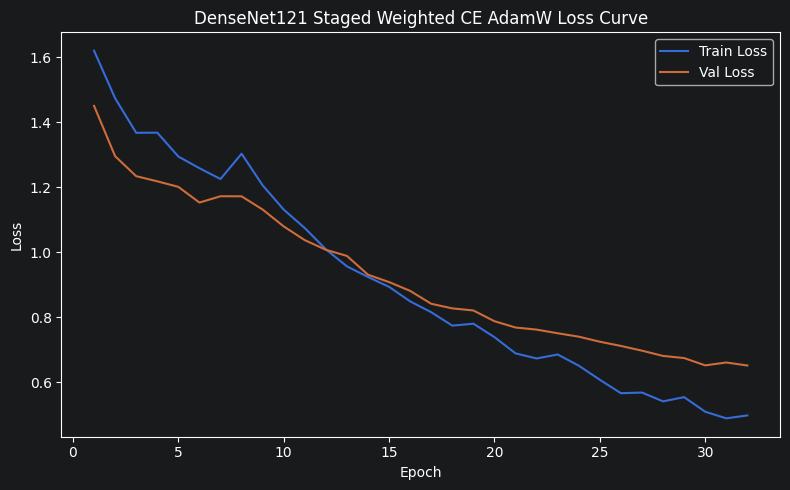

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_staged_weighted_ce_adamw_loss.png


In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Staged Weighted CE AdamW Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [10]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.7877
macro_f1: 0.7652
weighted_f1: 0.7766
mae: 0.2534
qwk: 0.9132
total_errors: 31
adjacent_errors: 27
distant_errors: 4
total_error_rate: 0.2123
adjacent_error_rate: 0.1849
distant_error_rate: 0.0274


In [11]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7551
macro_f1: 0.7331
weighted_f1: 0.7514
mae: 0.3503
qwk: 0.8500
total_errors: 72
adjacent_errors: 48
distant_errors: 24
total_error_rate: 0.2449
adjacent_error_rate: 0.1633
distant_error_rate: 0.0816
              precision    recall  f1-score   support

     0Normal       0.76      0.85      0.80        91
   1Doubtful       0.80      0.73      0.76        88
       2Mild       0.47      0.42      0.44        38
   3Moderate       0.87      0.74      0.80        35
     4Severe       0.80      0.93      0.86        42

    accuracy                           0.76       294
   macro avg       0.74      0.73      0.73       294
weighted avg       0.75      0.76      0.75       294



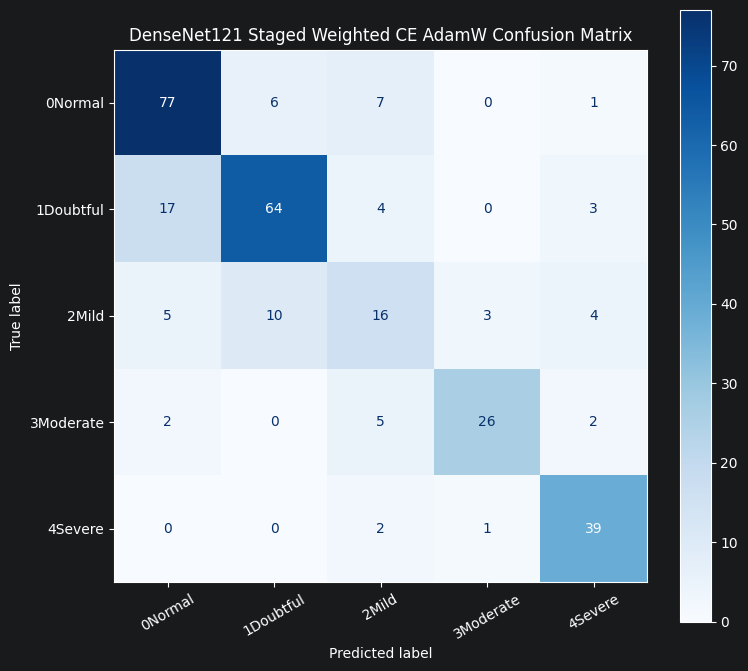

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_staged_weighted_ce_adamw_confusion_matrix.png


In [12]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Staged Weighted CE AdamW Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
